<a href="https://colab.research.google.com/github/radwaelreedy/DEPI_Tech_Journey/blob/main/Assignment_Ensemble_Models_Text_Classification_For_IT_Support_Ticket%20/%20Assignment_Ensemble_Models_Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
np.random.seed(1)

In [ ]:
data = pd.read_csv('/content/IT Support Ticket Data.csv')

In [ ]:
data

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."
...,...,...,...,...,...
29646,29646,"Hello Customer Support Team,My name is name. I...",IT Support,high,"['Technical Support', 'Urgent Issue', 'Service..."
29647,29647,"Dear Customer Support Team,We are currently en...",IT Support,high,"['Service Disruption', 'IT Support', 'Urgent I..."
29648,29648,"Dear Customer Support Team,Our Cisco Router IS...",Technical Support,high,"['Technical Support', 'Network Issue', 'Urgent..."
29649,29649,"Dear IT Services Support Team, I am writing to...",Technical Support,high,"['Urgent Issue', 'Service Disruption', 'Incide..."


In [ ]:
data.head(1)

,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."


In [ ]:
data.head()

,Unnamed: 0,Body,Department,Priority,Tags
0,0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."


In [ ]:
data.shape

(29651, 5)

In [ ]:
[len(data)] , [data.size], [data.columns], [data.dtypes]

([29650],
 [118600],
 [Index(['Body', 'Department', 'Priority', 'Tags'], dtype='object')],
 [Body          object
  Department    object
  Priority      object
  Tags          object
  dtype: object])

In [ ]:
data.columns.tolist()

['Body', 'Department', 'Priority', 'Tags']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29651 entries, 0 to 29650
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  29651 non-null  int64 
 1   Body        29650 non-null  object
 2   Department  29651 non-null  object
 3   Priority    29651 non-null  object
 4   Tags        29651 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.1+ MB


In [ ]:
data.isnull().sum().sum()

np.int64(1)

In [ ]:
data = data.dropna()

In [ ]:
data.drop(columns = ['Unnamed: 0'], inplace = True)

/tmp/ipython-input-1260734308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns = ['Unnamed: 0'], inplace = True)


In [ ]:
data

,Body,Department,Priority,Tags
0,"Dear Customer Support Team,I am writing to rep...",Technical Support,high,"['Account', 'Disruption', 'Outage', 'IT', 'Tec..."
1,"Dear Customer Support Team,I hope this message...",Returns and Exchanges,medium,"['Product', 'Feature', 'Tech Support']"
2,"Dear Customer Support Team,I hope this message...",Billing and Payments,low,"['Billing', 'Payment', 'Account', 'Documentati..."
3,"Dear Support Team,I hope this message reaches ...",Sales and Pre-Sales,medium,"['Product', 'Feature', 'Feedback', 'Tech Suppo..."
4,"Dear Customer Support,I hope this message reac...",Technical Support,high,"['Feature', 'Product', 'Documentation', 'Feedb..."
...,...,...,...,...
29646,"Hello Customer Support Team,My name is name. I...",IT Support,high,"['Technical Support', 'Urgent Issue', 'Service..."
29647,"Dear Customer Support Team,We are currently en...",IT Support,high,"['Service Disruption', 'IT Support', 'Urgent I..."
29648,"Dear Customer Support Team,Our Cisco Router IS...",Technical Support,high,"['Technical Support', 'Network Issue', 'Urgent..."
29649,"Dear IT Services Support Team, I am writing to...",Technical Support,high,"['Urgent Issue', 'Service Disruption', 'Incide..."


In [ ]:
data.nunique()

,0
Body,25055
Department,10
Priority,3
Tags,12945


In [ ]:
data.duplicated().sum()

np.int64(4428)

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('IT Support Ticket Data.csv')

# Preprocessing: Handle nulls in the text column
df = df.dropna(subset=['Body'])

# 1. Check Class Distribution
class_dist = df['Department'].value_counts()
class_dist_pct = df['Department'].value_counts(normalize=True) * 100

# 2. Identify Class Imbalance (Ratio between largest and smallest class)
imbalance_ratio = class_dist.max() / class_dist.min()

# 3. Compute Text Length per ticket
df['text_length'] = df['Body'].apply(len)

# 4. Compute Average Text Length per class
avg_len_per_class = df.groupby('Department')['text_length'].mean()

# 5. Identify Short/Noisy Texts (Threshold set at < 50 characters)
short_texts = df[df['text_length'] < 50]

# Display Summary
print("--- Class Distribution ---")
print(class_dist)
print(f"\nImbalance Ratio (Max/Min): {imbalance_ratio:.2f}")
print("\n--- Average Text Length per Class ---")
print(avg_len_per_class)
print(f"\nTotal Short Texts (< 50 chars): {len(short_texts)}")

--- Class Distribution ---
Department
Technical Support                  8617
Product Support                    5538
Customer Service                   4482
IT Support                         3500
Billing and Payments               3017
Returns and Exchanges              1467
Service Outages and Maintenance    1157
Sales and Pre-Sales                 885
Human Resources                     568
General Inquiry                     419
Name: count, dtype: int64

Imbalance Ratio (Max/Min): 20.57

--- Average Text Length per Class ---
Department
Billing and Payments               385.476964
Customer Service                   385.279786
General Inquiry                    398.374702
Human Resources                    351.563380
IT Support                         381.944286
Product Support                    379.590646
Returns and Exchanges              376.169734
Sales and Pre-Sales                382.404520
Service Outages and Maintenance    381.466724
Technical Support                  393

In [ ]:
data['Tags'].value_counts()

,count
Tags,
"['Bug', 'Performance', 'IT', 'Tech Support']",878
"['Feedback', 'Sales', 'IT', 'Tech Support']",518
"['Feature', 'Documentation', 'IT', 'Tech Support']",328
"['Feature', 'Feedback', 'IT', 'Tech Support']",303
"['Bug', 'Crash', 'Performance', 'IT', 'Tech Support']",280
...,...
"['Feedback', 'Performance', 'Product', 'Feature', 'Marketing', 'Tech Support']",1
"['Bug', 'Integration', 'Performance', 'IT', 'Tech Support']",1
"['Billing', 'Account', 'Recovery', 'IT', 'Tech Support']",1


In [ ]:
#preprocessing function to clean data
def preprocessing(text):
  text  = re.sub(r'\W', ' ', text) #Remove non_word characters
  text = re.sub(r'\s', ' ', text) #Remove extra spaces
  text = text.lower() #convert to lowercase
  text = text.strip() #Remove leading/ trailing whitespaces
  return text

In [ ]:
# 3. Call the function using .apply()
# This creates a new column called 'Cleaned_Body'
df['Cleaned_Body'] = df['Body'].apply(preprocessing)

# 4. View the results
print(df[['Body', 'Cleaned_Body']].head())

# 5. Optional: Save the cleaned data to a new file
df.to_csv('Cleaned_IT_Support_Ticket_Data.csv', index=False)

                                                Body  \
0  Dear Customer Support Team,I am writing to rep...   
1  Dear Customer Support Team,I hope this message...   
2  Dear Customer Support Team,I hope this message...   
3  Dear Support Team,I hope this message reaches ...   
4  Dear Customer Support,I hope this message reac...   

                                        Cleaned_Body  
0  dear customer support team i am writing to rep...  
1  dear customer support team i hope this message...  
2  dear customer support team i hope this message...  
3  dear support team i hope this message reaches ...  
4  dear customer support i hope this message reac...  


In [ ]:
# 1. Initialize the Vectorizer with specific parameters
tfidf = TfidfVectorizer(
    max_features=5000,      # Select top 5000 terms
    ngram_range=(1, 2),      # Use both single words and two-word phrases
    stop_words='english',    # Remove common filler words
    min_df=5,                # Remove very rare words (appear in < 5 docs)
    max_df=0.8               # Remove corpus-wide common words (appear in > 80% docs)
)

# 2. Fit and transform the cleaned text
tfidf_matrix = tfidf.fit_transform(df['Cleaned_Body'])

# 3. Inspect dimensionality
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (29650, 5000)


In [ ]:
from sklearn.preprocessing import LabelEncoder
# 1. Encode Target Labels (Convert department names to numbers 0-9)
le = LabelEncoder()
y = le.fit_transform(df['Department'])

# 2. Split Data with Stratification
# 'stratify=y' ensures the training and validation sets have the same % of each class
X_train, X_val, y_train, y_val = train_test_split(
    tfidf_matrix, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Initialize and Train the Model
# We set class_weight='balanced' to handle the imbalance we identified earlier
model = XGBClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:09:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Accuracy: 0.6747
                                 precision    recall  f1-score   support

           Billing and Payments       0.93      0.81      0.87       604
               Customer Service       0.64      0.58      0.61       896
                General Inquiry       0.98      0.49      0.65        84
                Human Resources       0.94      0.53      0.67       114
                     IT Support       0.75      0.50      0.60       700
                Product Support       0.64      0.62      0.63      1108
          Returns and Exchanges       0.89      0.51      0.65       293
            Sales and Pre-Sales       0.85      0.51      0.64       177
Service Outages and Maintenance       0.91      0.65      0.76       231
              Technical Support       0.58      0.85      0.69      1723

                       accuracy                           0.67      5930
                      macro avg       0.81      0.60      0.68      5930
                   we

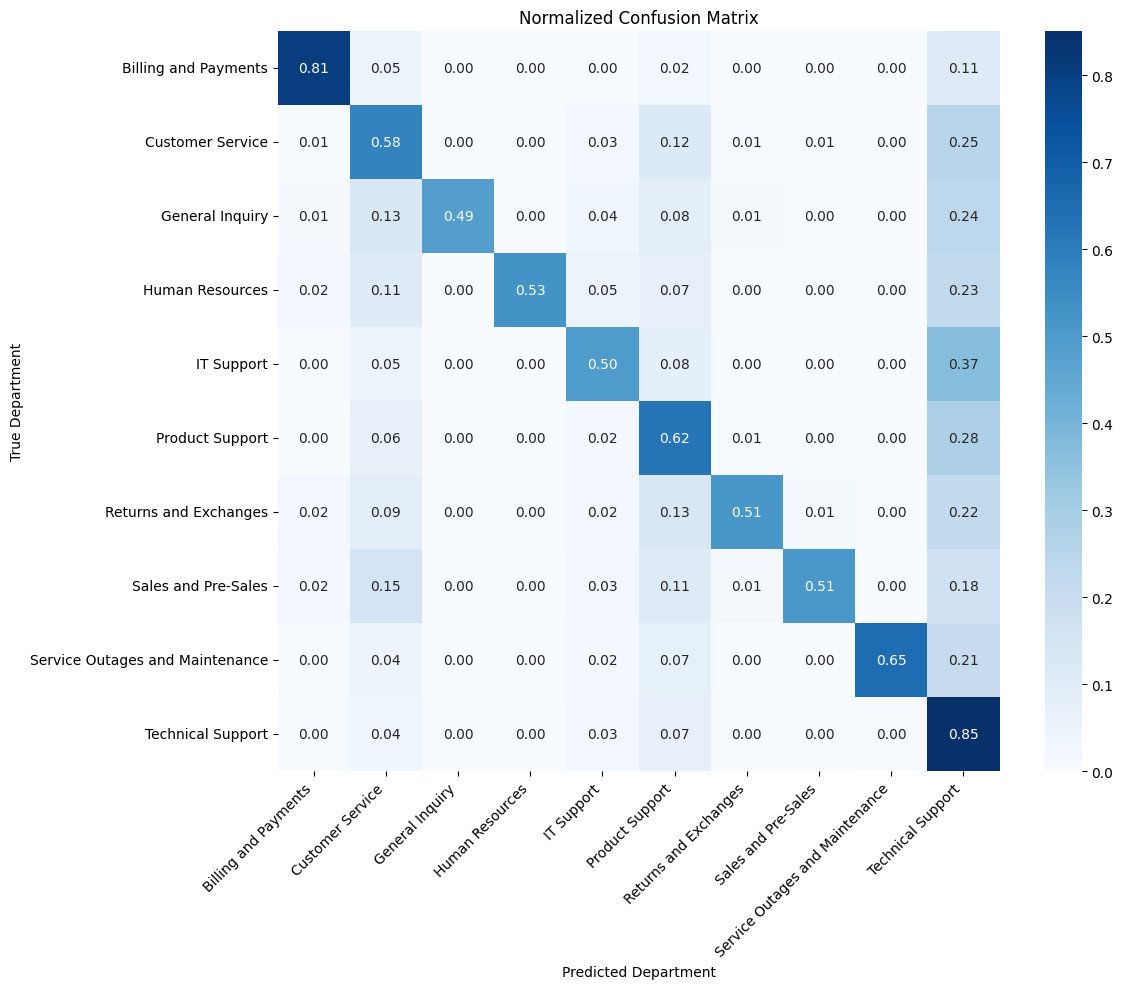

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
# Normalize to see percentages (useful for imbalanced classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# 2. Plotting using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True Department')
plt.xlabel('Predicted Department')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png')